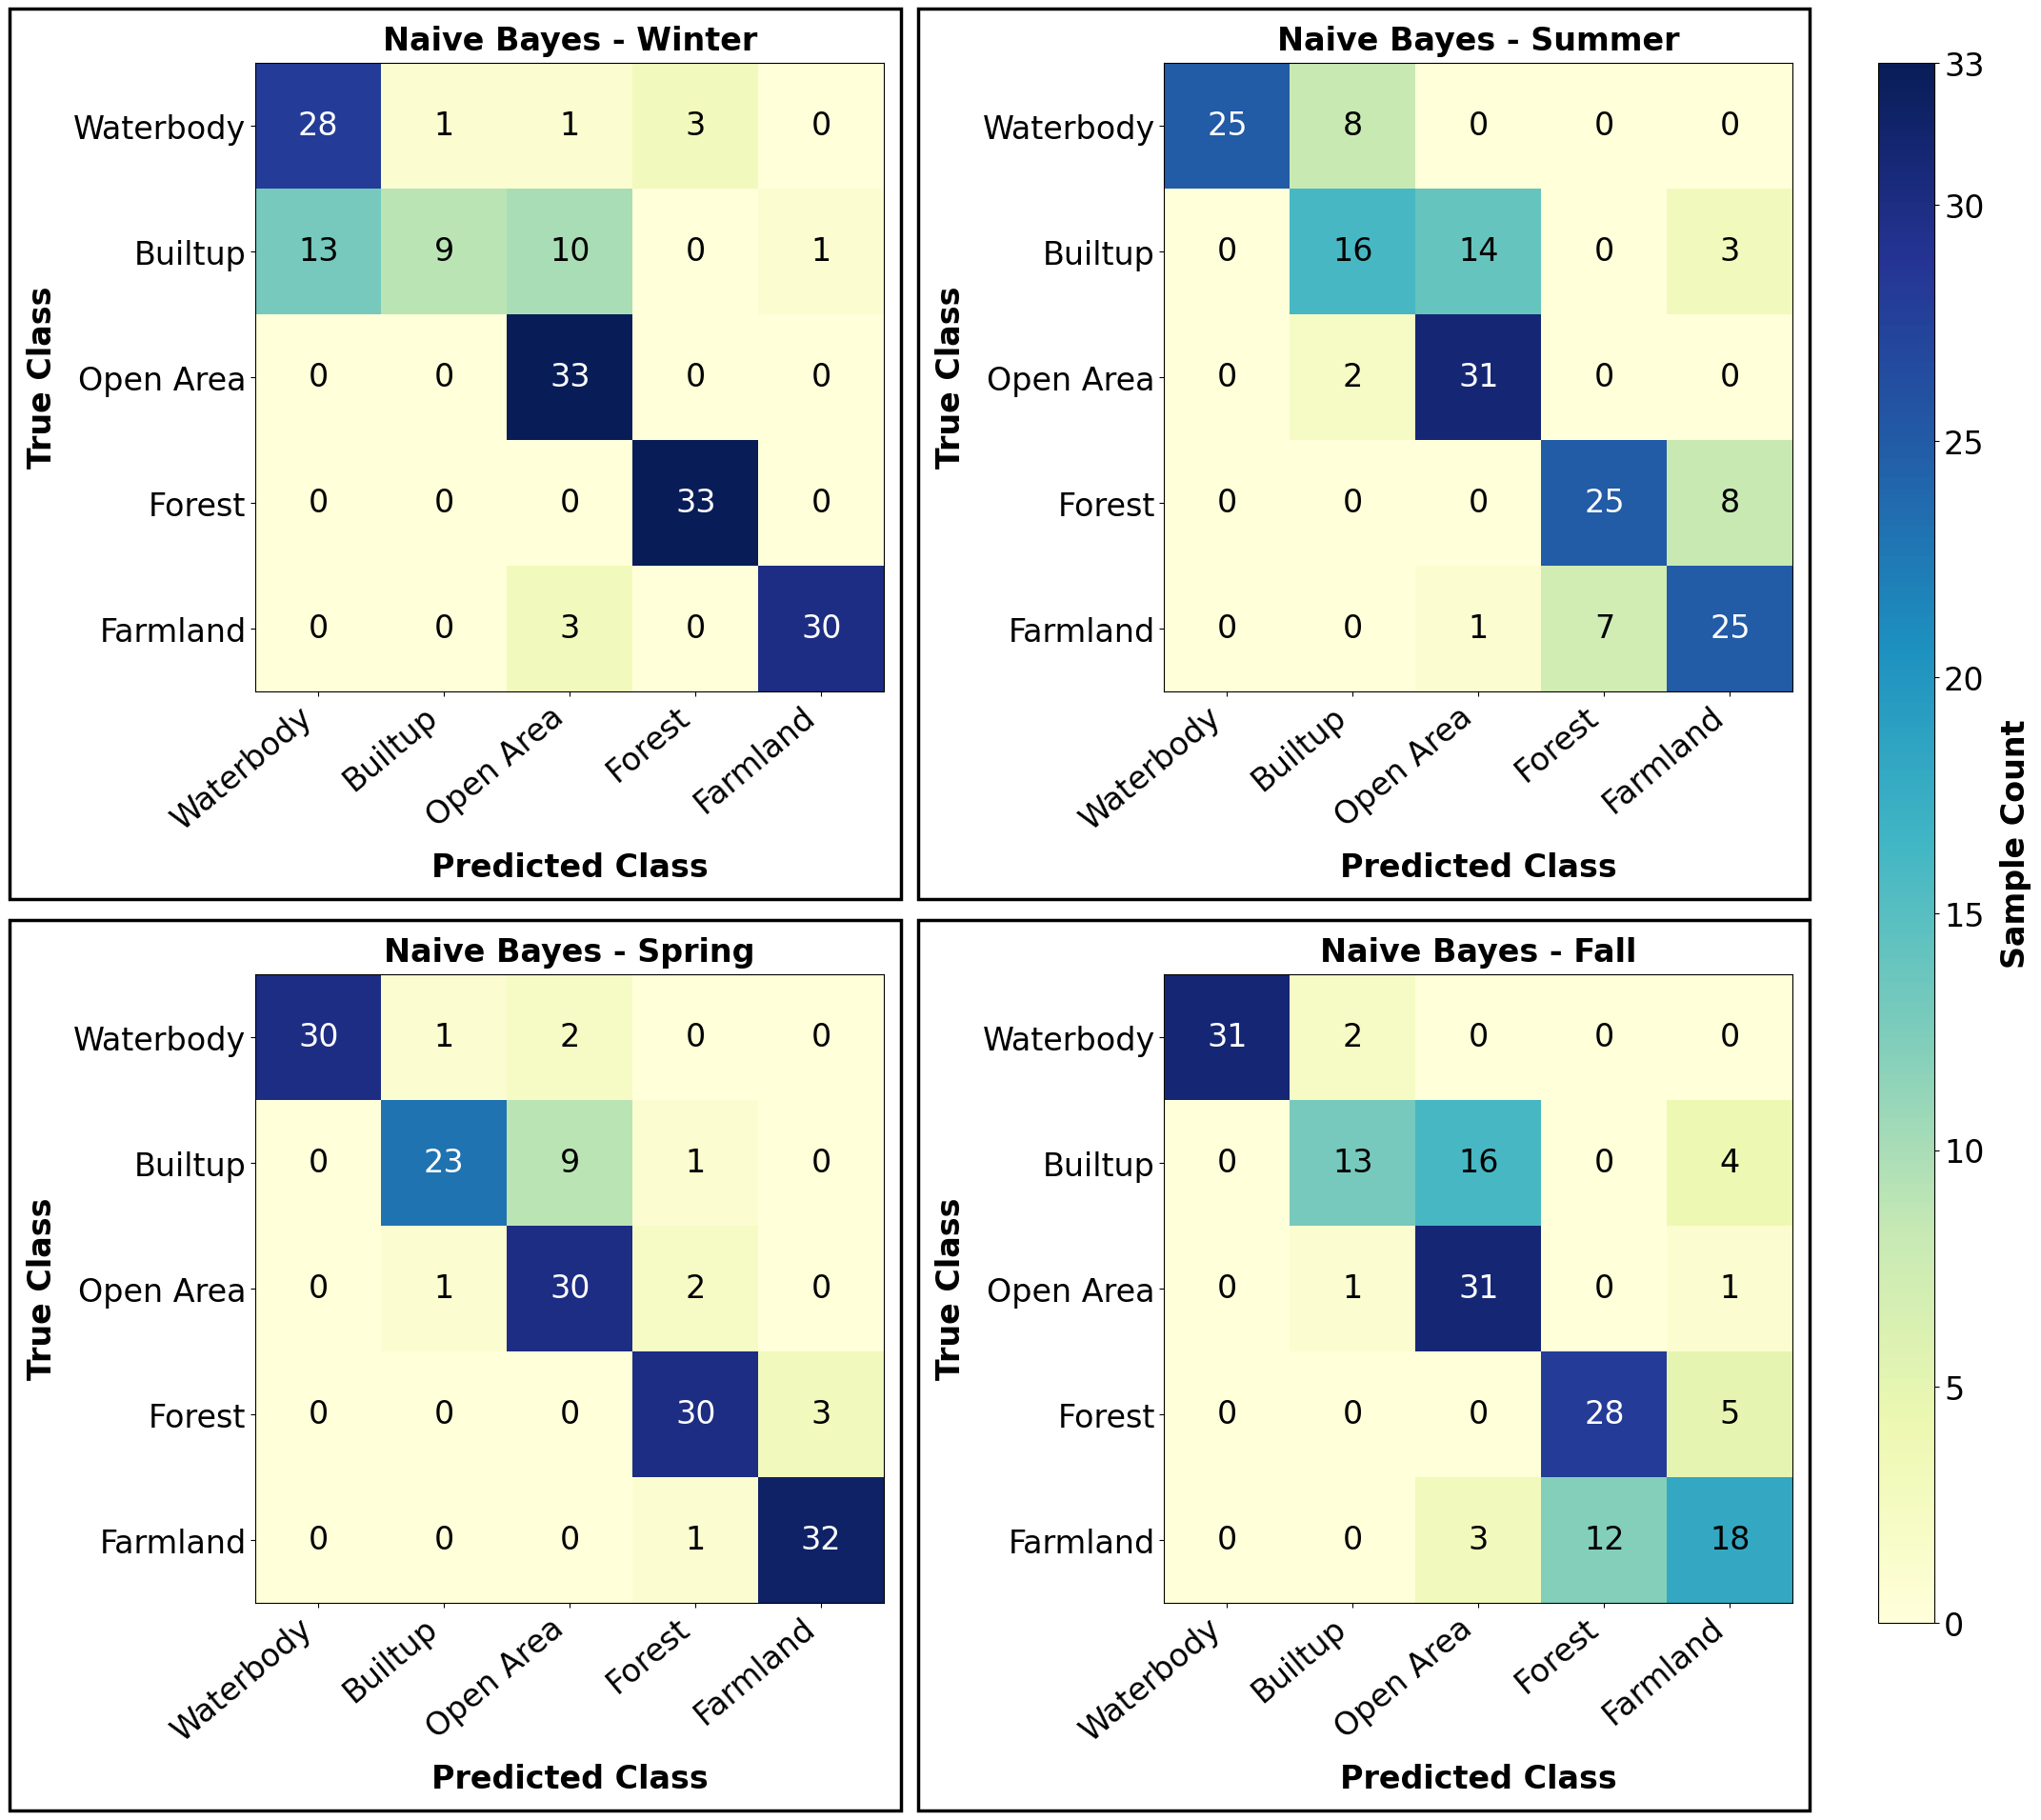

Saved → /content/drive/MyDrive/Paper_with_the_boys/NB_confusion_matrices_4panel_v2.jpeg


In [ ]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import FancyBboxPatch

# ── File paths ─────────────────────────────────────────────────────────────
# Place the four CSV files in the same folder as this notebook, or update
# the paths below to match your directory structure.
# CSV files are available from the Mendeley dataset:
# https://data.mendeley.com/datasets/wxbwz869jg/2

csv_paths = {
    "Winter": "NB_Winter_confusion_matrix_csv.csv",
    "Summer": "NB_Summer_confusion_matrix_csv.csv",
    "Spring": "NB_Spring_confusion_matrix_csv.csv",
    "Fall":   "NB_Fall_confusion_matrix_csv.csv",
}

class_labels = ["Waterbody", "Builtup", "Open Area", "Forest", "Farmland"]

def load_cm(path):
    df = pd.read_csv(path)
    df['row'] = df['row'].apply(ast.literal_eval)
    return np.vstack(df['row'].values)

cms = {season: load_cm(path) for season, path in csv_paths.items()}

# ── Plot settings ───────────────────────────────────────────────────────────
vmin = 0
vmax = 33

TITLE_FS = 24
LABEL_FS = 24
TICK_FS  = 24
CELL_FS  = 24
CBAR_FS  = 24

fig, axes = plt.subplots(2, 2, figsize=(22, 21))
seasons = ["Winter", "Summer", "Spring", "Fall"]

im_ref = None

for ax, season in zip(axes.flatten(), seasons):
    cm = cms[season]

    im = ax.imshow(cm, cmap="YlGnBu", vmin=vmin, vmax=vmax)
    im_ref = im

    ax.set_title(f"Naive Bayes - {season}", fontsize=TITLE_FS,
                 fontweight="bold", pad=10)
    ax.set_xlabel("Predicted Class", fontsize=LABEL_FS,
                  labelpad=12, fontweight="bold")
    ax.set_ylabel("True Class", fontsize=LABEL_FS,
                  labelpad=12, fontweight="bold")

    ax.set_xticks(np.arange(len(class_labels)))
    ax.set_yticks(np.arange(len(class_labels)))
    ax.set_xticklabels(class_labels, rotation=40, ha="right", fontsize=TICK_FS)
    ax.set_yticklabels(class_labels, fontsize=TICK_FS)

    threshold = vmax * 0.55
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] >= threshold else "black"
            ax.text(j, i, str(cm[i, j]),
                    ha="center", va="center",
                    fontsize=CELL_FS, color=color)

fig.subplots_adjust(right=0.88, hspace=0.45, wspace=0.35)

cbar_ax = fig.add_axes([0.91, 0.1, 0.027, 0.78])
cbar = fig.colorbar(im_ref, cax=cbar_ax)

cbar_ticks = list(range(0, 31, 5)) + [33]
cbar.set_ticks(cbar_ticks)
cbar.set_ticklabels([str(t) for t in cbar_ticks], fontsize=CBAR_FS)
cbar.set_label("Sample Count", fontsize=CBAR_FS,
               labelpad=12, fontweight="bold")

# ── Draw black outline around each panel ───────────────────────────────────
fig.canvas.draw()

for ax in axes.flatten():
    bbox = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(
        fig.transFigure.inverted()
    )
    pad = 0.008
    rect = plt.Rectangle(
        (bbox.x0 - pad, bbox.y0 - pad),
        bbox.width  + 2 * pad,
        bbox.height + 2 * pad,
        linewidth=2.5,
        edgecolor='black',
        facecolor='none',
        transform=fig.transFigure,
        clip_on=False
    )
    fig.add_artist(rect)

# ── Save output ─────────────────────────────────────────────────────────────
out_path = "NB_confusion_matrices_4panel.jpeg"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")